In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import requests 
import opendatasets as od 
from pathlib import Path

c:\Users\Flami\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
dataset_url = "https://www.kaggle.com/datasets/residentmario/ramen-ratings/data"

In [3]:
data_dir = od.download(dataset_url)

Skipping, found downloaded files in ".\ramen-ratings" (use force=True to force download)


In [4]:
data_dir = Path("ramen-ratings")
csv_path = data_dir / "ramen-ratings.csv"

### THE BIG QUESTION:
- DOES JAPAN HAVE THE BEST RAMEN?

In [5]:
df = pd.read_csv(csv_path)
df.head(5)

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [6]:
print(f"Shape: {df.shape}")
print('-'*1000)
df.info()

Shape: (2580, 7)
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Data Cleaning

In [7]:
feature_col = [c for c in df.columns if c not in ('Review #', 'Stars')]

for col in feature_col:
    print(f"{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())
    print('-' * 50)

Brand (355 unique values):
<ArrowStringArray>
[             'New Touch',               'Just Way',                 'Nissin',
                'Wei Lih',         'Ching's Secret',          'Samyang Foods',
                'Acecook',            'Ikeda Shoku',             'Ripe'n'Dry',
                   'KOKA',
 ...
                'Higashi',                'Sakurai',     'Global Inspiration',
          'Teriyaki Time', 'Hua Feng Noodle Expert',            'Kim Ve Wong',
                  'Smack',                  'Sutah',                 'Tung-I',
               'Westbrae']
Length: 355, dtype: str
--------------------------------------------------
Variety (2413 unique values):
<ArrowStringArray>
[                                            'T's Restaurant Tantanmen ',
           'Noodles Spicy Hot Sesame Spicy Hot Sesame Guan-miao Noodles',
                                         'Cup Noodles Chicken Vegetable',
                                         'GGE Ramen Snack Tomato Flavor',
 

In [8]:
df_clean = df.copy()
df_clean[["Top Ten Year", "Top Ten Rank"]] = df_clean["Top Ten"].str.extract(r"(\d{4})\s*#(\d+)")
df_clean["Top Ten Year"] = df_clean["Top Ten Year"].astype("Int64")
df_clean["Top Ten Rank"] = df_clean["Top Ten Rank"].astype("Int64")
df_clean["Stars"] = pd.to_numeric(df_clean["Stars"], errors="coerce")
df_clean = df_clean.dropna(subset=["Style", "Stars"])

df_clean

,Review #,Brand,Variety,Style,Country,Stars,Top Ten,Top Ten Year,Top Ten Rank
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN,<NA>,<NA>
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00,NaN,<NA>,<NA>
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN,<NA>,<NA>
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN,<NA>,<NA>
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...
2575,5,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,Vietnam,3.50,NaN,<NA>,<NA>
2576,4,Wai Wai,Oriental Style Instant Noodles,Pack,Thailand,1.00,NaN,<NA>,<NA>
2577,3,Wai Wai,Tom Yum Shrimp,Pack,Thailand,2.00,NaN,<NA>,<NA>
2578,2,Wai Wai,Tom Yum Chili Flavor,Pack,Thailand,2.00,NaN,<NA>,<NA>


# Feature Engineering

Defining flavors and categorizing them to similar groups so that we can use this to find the most popular flavors for each country

In [9]:
print(df_clean["Variety"].value_counts().to_string())

Variety
Beef                                                                                                7
Chicken                                                                                             7
Yakisoba                                                                                            6
Vegetable                                                                                           6
Artificial Chicken                                                                                  6
Miso Ramen                                                                                          5
Curry Flavour Instant Noodles                                                                       4
Curry Udon                                                                                          4
Instant Noodles Chicken Flavour                                                                     4
Spicy Beef                                                                

In [10]:
flavor_keywords = {
    "Chicken": ["chicken"],
    "Beef": ["beef"],
    "Pork": ["pork"],
    "Shrimp": ["shrimp", "prawn"],
    "Seafood": ["seafood"],
    "Crab": ["crab"],
    "Spicy": ["spicy"],
    "Curry": ["curry"],
    "Tom Yum": ["tom yum"],
    "Laksa": ["laksa"],
    "Vegetable": ["vegetable"],
    "Tomato": ["tomato"],
    "Miso": ["miso"],
    "Tonkotsu": ["tonkotsu"],
    "Shoyu": ["shoyu"],
    "Sesame": ["sesame"],
    "Garlic": ["garlic"],
    "Mushroom": ["mushroom"],
    "Kimchi": ["kimchi"],
    "Onion": ["onion"],
    "Duck": ["duck"],
}

for keyword in flavor_keywords:
    col_name = keyword
    df_clean[col_name] = df_clean["Variety"].str.contains(keyword, case=False, na=False)

# Rows that didn't match any defined flavor keyword get bucketed into "Other" so every row is accounted for
df_clean["Other"] = ~df_clean[list(flavor_keywords.keys())].any(axis=1)
flavor_keywords["Other"] = []

In [11]:
# Fraction of each country's ramens that hit each flavor keyword
df_clean.groupby("Country")[list(flavor_keywords.keys())].mean()

,Chicken,Beef,Pork,Shrimp,Seafood,Crab,Spicy,Curry,Tom Yum,Laksa,...,Miso,Tonkotsu,Shoyu,Sesame,Garlic,Mushroom,Kimchi,Onion,Duck,Other
Country,,,,,,,,,,,,,,,,,,,,,
Australia,0.363636,0.136364,0.000000,0.000000,0.000000,0.000000,0.136364,0.000000,0.000000,0.045455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.318182
Bangladesh,0.142857,0.142857,0.000000,0.142857,0.000000,0.000000,0.142857,0.142857,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.285714
Brazil,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Cambodia,0.200000,0.200000,0.200000,0.400000,0.000000,0.000000,0.000000,0.200000,0.400000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Canada,0.365854,0.219512,0.000000,0.048780,0.024390,0.000000,0.195122,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.048780,0.000000,0.000000,0.170732
China,0.089286,0.297619,0.125000,0.029762,0.071429,0.005952,0.226190,0.000000,0.000000,0.005952,...,0.000000,0.000000,0.005952,0.005952,0.000000,0.047619,0.000000,0.011905,0.005952,0.238095
Colombia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Dubai,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Estonia,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
from sklearn.preprocessing import OneHotEncoder
df_engineered = df_clean.copy()
encoder_1 = OneHotEncoder(sparse_output=False)
country_encoded = encoder_1.fit_transform(df_clean[["Country"]])
country_encoded_df = pd.DataFrame(
    country_encoded,
    columns=encoder_1.get_feature_names_out(["Country"]),
    index=df_clean.index #Note this is away for the onehote encoder to ensure its matching up with the df_clean index
)

encoder_2 = OneHotEncoder(sparse_output=False)
style_encoded = encoder_2.fit_transform(df_clean[["Style"]])
style_encoded_df = pd.DataFrame(
    style_encoded,
    columns=encoder_2.get_feature_names_out(["Style"]),
    index=df_clean.index
)


df_engineered = pd.concat([df_clean, country_encoded_df, style_encoded_df], axis=1)
df_engineered = df_engineered.drop(columns = ["Country"])
df_engineered = df_engineered.drop(columns = ["Style"])
df_engineered

,Review #,Brand,Variety,Stars,Top Ten,Top Ten Year,Top Ten Rank,Chicken,Beef,Pork,...,Country_USA,Country_United States,Country_Vietnam,Style_Bar,Style_Bowl,Style_Box,Style_Can,Style_Cup,Style_Pack,Style_Tray
0,2580,New Touch,T's Restaurant Tantanmen,3.75,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,1.00,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2578,Nissin,Cup Noodles Chicken Vegetable,2.25,NaN,<NA>,<NA>,True,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,2.75,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2576,Ching's Secret,Singapore Curry,3.75,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2575,5,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",3.50,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2576,4,Wai Wai,Oriental Style Instant Noodles,1.00,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2577,3,Wai Wai,Tom Yum Shrimp,2.00,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2578,2,Wai Wai,Tom Yum Chili Flavor,2.00,NaN,<NA>,<NA>,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Step 1
- Lets first see which countries along with which brands have "top ten ratings"
- Moreover lets see if what favorite brand of Ramen is of every country

In [13]:
df_clean[df_clean["Brand"] == "New Touch"]

,Review #,Brand,Variety,Style,Country,Stars,Top Ten,Top Ten Year,Top Ten Rank,Chicken,...,Miso,Tonkotsu,Shoyu,Sesame,Garlic,Mushroom,Kimchi,Onion,Duck,Other
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN,<NA>,<NA>,False,...,False,False,False,False,False,False,False,False,False,True
34,2546,New Touch,Sugo-Men Kyoto Backfat Shoyu Ramen,Bowl,Japan,3.75,NaN,<NA>,<NA>,False,...,False,False,True,False,False,False,False,False,False,False
151,2429,New Touch,T's Restaurant Sura Tanmen,Cup,Japan,4.00,NaN,<NA>,<NA>,False,...,False,False,False,False,False,False,False,False,False,True
328,2252,New Touch,Sugomen Sano Ramen,Bowl,Japan,5.00,NaN,<NA>,<NA>,False,...,False,False,False,False,False,False,False,False,False,True
637,1943,New Touch,Sugomen Niigata Seabura Shoyu Ramen,Bowl,Japan,5.00,NaN,<NA>,<NA>,False,...,False,False,True,False,False,False,False,False,False,False
812,1768,New Touch,Negi Miso No Ippin Ramen,Bowl,Japan,5.00,NaN,<NA>,<NA>,False,...,True,False,False,False,False,False,False,False,False,False
820,1760,New Touch,Homestyle Tonjiru,Bowl,Japan,4.50,NaN,<NA>,<NA>,False,...,False,False,False,False,False,False,False,False,False,True
1041,1539,New Touch,Kimchi Noodle,Bowl,Japan,3.50,NaN,<NA>,<NA>,False,...,False,False,False,False,False,False,True,False,False,False
1533,1047,New Touch,Yakisoba Noodle,Tray,Japan,4.00,NaN,<NA>,<NA>,False,...,False,False,False,False,False,False,False,False,False,True


In [14]:
df_top10 = df_clean[df_clean["Top Ten"].notna()]
df_top10 = df_top10.drop(columns = "Top Ten")
df_top10 = df_top10.dropna()
print(f"Amount of Rows: {df_top10.shape[0]}")
df_top10.head(10)

Amount of Rows: 37


,Review #,Brand,Variety,Style,Country,Stars,Top Ten Year,Top Ten Rank,Chicken,Beef,...,Miso,Tonkotsu,Shoyu,Sesame,Garlic,Mushroom,Kimchi,Onion,Duck,Other
616,1964,MAMA,Instant Noodles Coconut Milk Flavour,Pack,Myanmar,5.0,2016,10,False,False,...,False,False,False,False,False,False,False,False,False,True
633,1947,Prima Taste,Singapore Laksa Wholegrain La Mian,Pack,Singapore,5.0,2016,1,False,False,...,False,False,False,False,False,False,False,False,False,False
655,1925,Prima,Juzz's Mee Creamy Chicken Flavour,Pack,Singapore,5.0,2016,8,True,False,...,False,False,False,False,False,False,False,False,False,False
673,1907,Prima Taste,Singapore Curry Wholegrain La Mian,Pack,Singapore,5.0,2016,5,False,False,...,False,False,False,False,False,False,False,False,False,False
752,1828,Tseng Noodles,Scallion With Sichuan Pepper Flavor,Pack,Taiwan,5.0,2016,9,False,False,...,False,False,False,False,False,False,False,False,False,True
891,1689,Wugudaochang,Tomato Beef Brisket Flavor Purple Potato Noodle,Pack,China,5.0,2016,7,False,True,...,False,False,False,False,False,False,False,False,False,False
942,1638,A-Sha Dry Noodle,Veggie Noodle Tomato Noodle With Vine Ripened ...,Pack,Taiwan,5.0,2015,10,False,False,...,False,False,False,False,False,False,False,False,False,False
963,1617,MyKuali,Penang Hokkien Prawn Noodle (New Improved Taste),Pack,Malaysia,5.0,2015,7,False,False,...,False,False,False,False,False,False,False,False,False,True
995,1585,CarJEN,Nyonya Curry Laksa,Pack,Malaysia,5.0,2015,4,False,False,...,False,False,False,False,False,False,False,False,False,False
1059,1521,Maruchan,Gotsumori Sauce Yakisoba,Tray,Japan,5.0,2015,9,False,False,...,False,False,False,False,False,False,False,False,False,True


In [15]:
df_top10["Country"].value_counts()

Country
Singapore      7
Malaysia       6
Japan          6
South Korea    5
Indonesia      4
Thailand       3
Taiwan         2
Myanmar        1
China          1
USA            1
Hong Kong      1
Name: count, dtype: int64

# Top Styles of Ramen

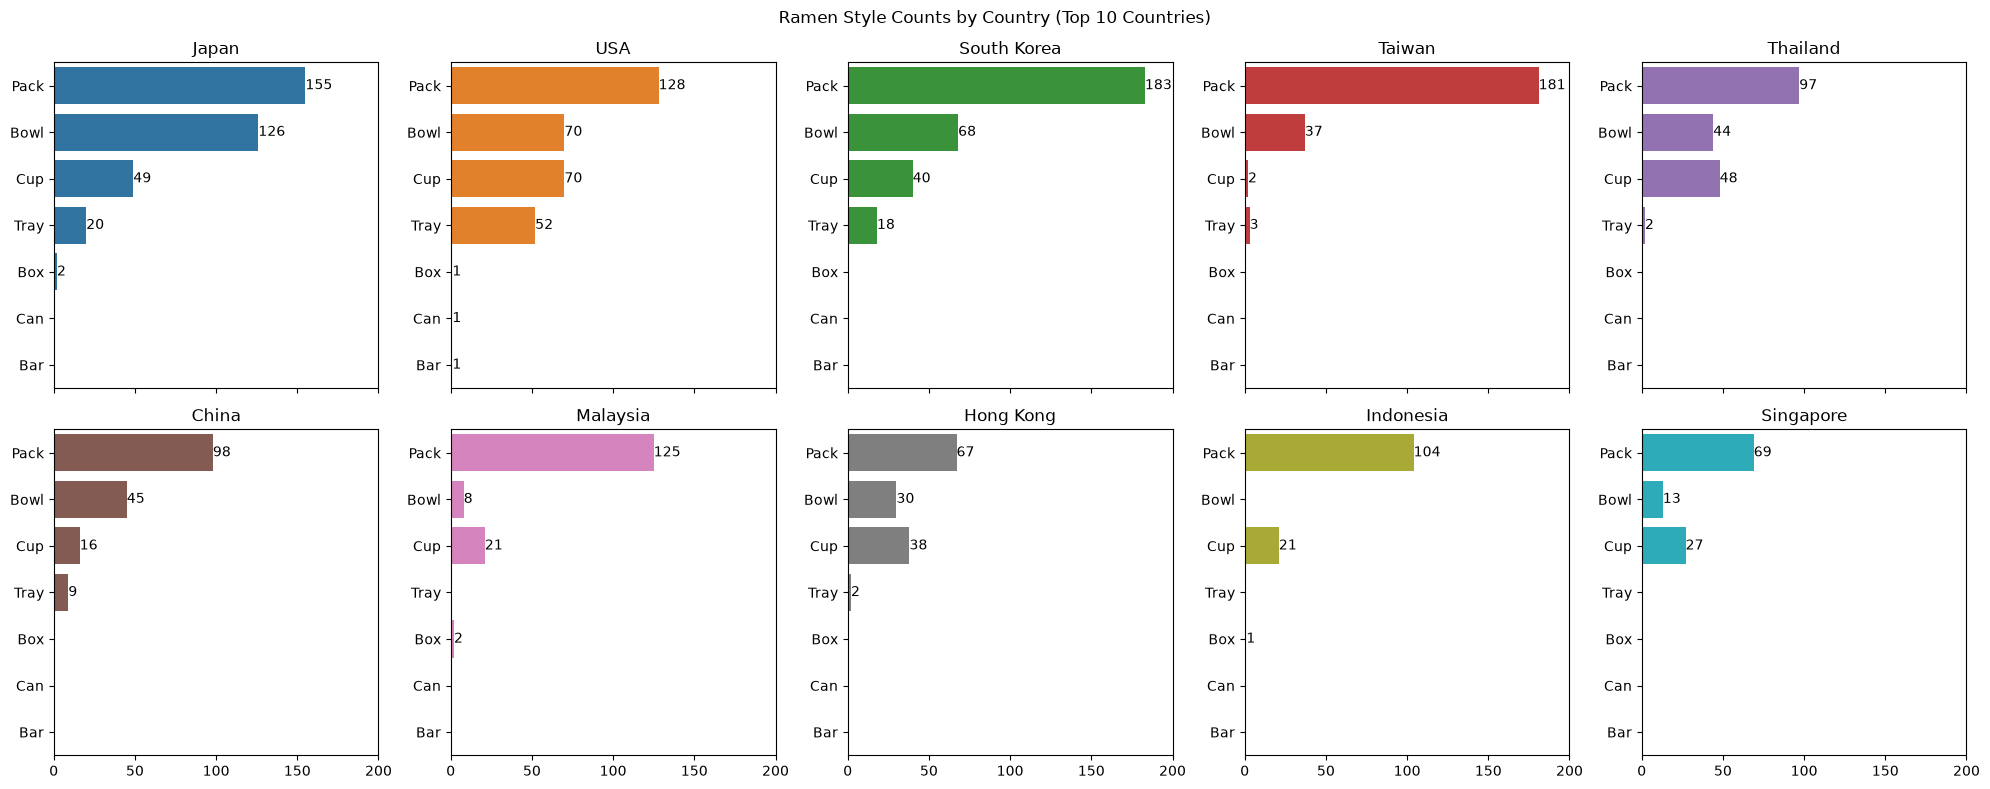

In [16]:
df_style = df.dropna(subset=["Style"]).copy()

top_countries = df_style["Country"].value_counts().nlargest(10).index
style_order = df_style["Style"].value_counts().index
colors = sns.color_palette("tab10", n_colors=len(top_countries))

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes = axes.flatten()

for ax, country, color in zip(axes, top_countries, colors):
    country_data = df_style[df_style["Country"] == country]
    sns.countplot(data=country_data, y="Style", order=style_order, ax=ax, color=color)
    ax.set_title(country)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0, 200)
    ax.bar_label(ax.containers[0])

fig.suptitle("Ramen Style Counts by Country (Top 10 Countries)")
plt.tight_layout()
plt.show()

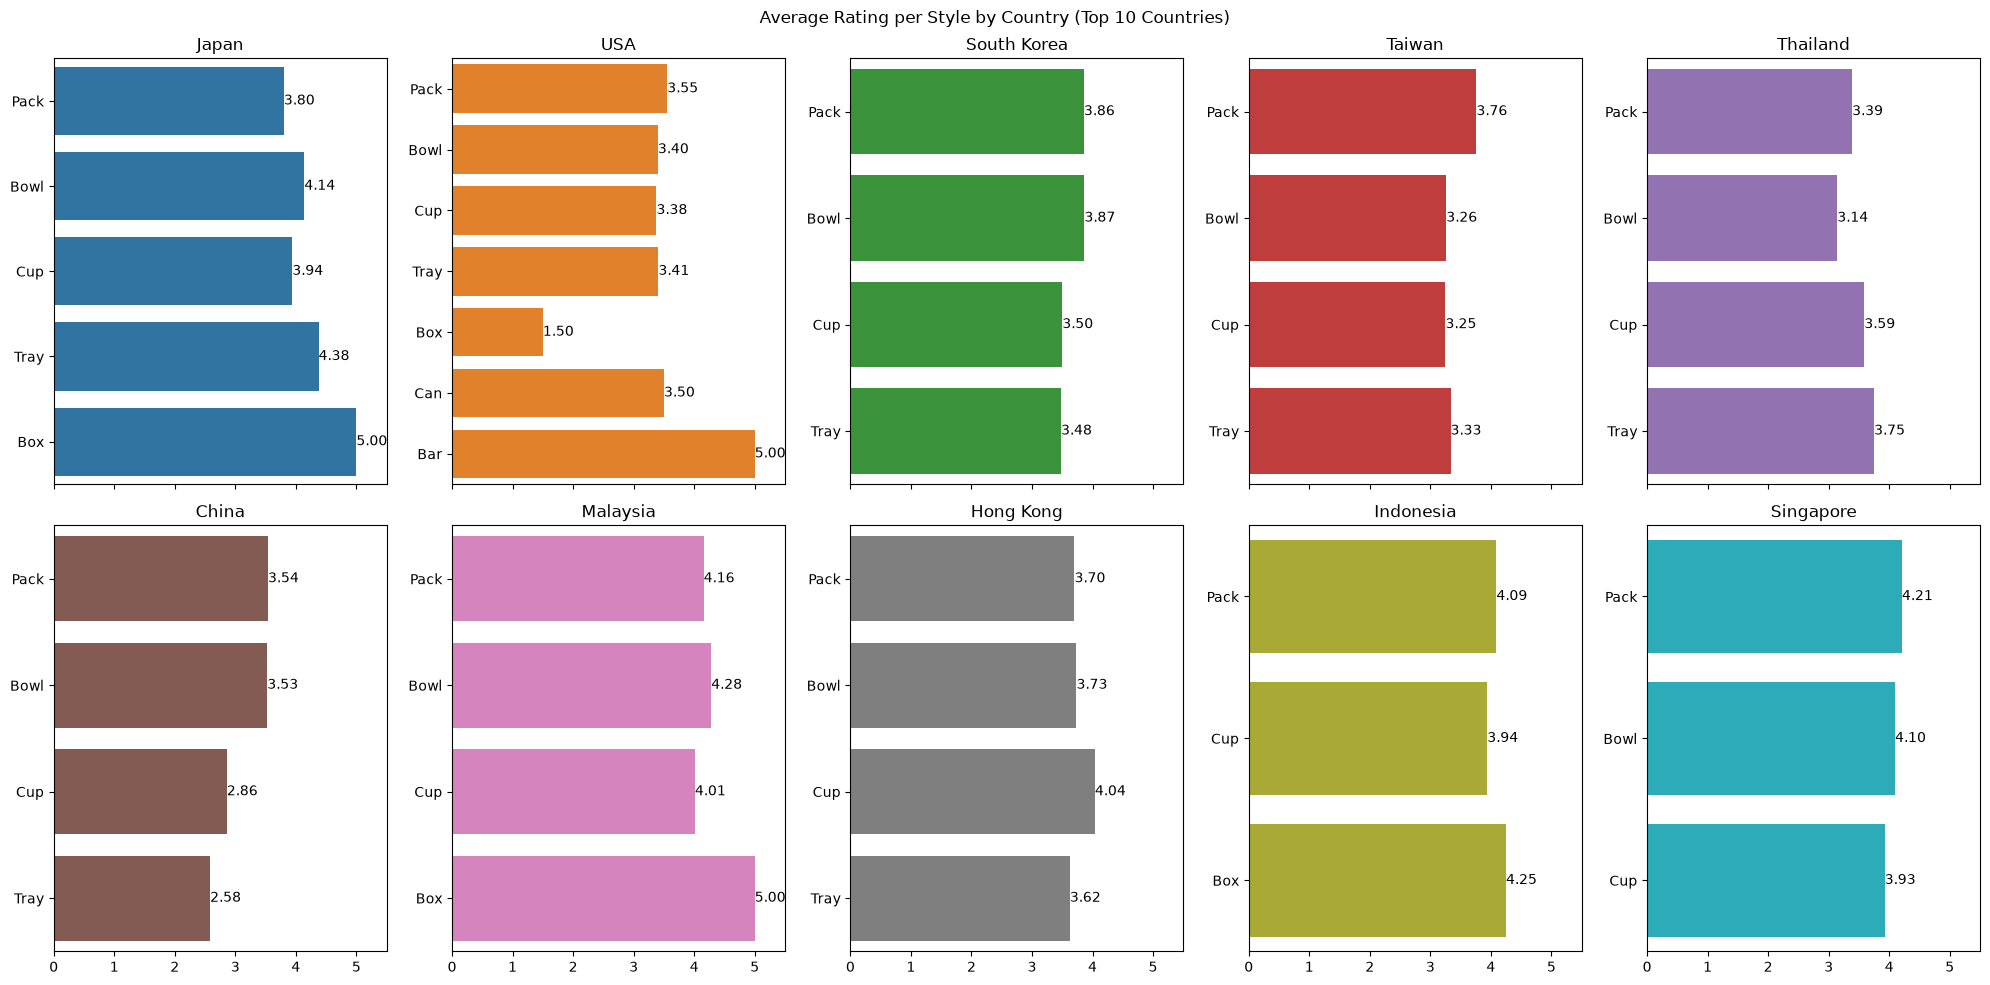

In [17]:
top_countries = df_clean["Country"].value_counts().nlargest(10).index
style_order = df_clean["Style"].value_counts().index
colors = sns.color_palette("tab10", n_colors=len(top_countries))

fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharex=True)
axes = axes.flatten()

for ax, country, color in zip(axes, top_countries, colors):
    country_data = df_clean[df_clean["Country"] == country]
    avg_rating = country_data.groupby("Style")["Stars"].mean().reindex(style_order).dropna()
    sns.barplot(x=avg_rating.values, y=avg_rating.index, ax=ax, color=color)
    ax.set_title(country)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0, 5.5)
    ax.bar_label(ax.containers[0], fmt="%.2f")

fig.suptitle("Average Rating per Style by Country (Top 10 Countries)")
plt.tight_layout()
plt.show()

There seems to be a preference of style for every Country. For example there are a lot of people in Japan who seem tor prefer Bowl Ramen based off of the rating for Bowl. (Note: we aren't considering box since there are only 2 counts). Meanwhile the trend thhroughout all countries is there is a fondess for Ramen in Packs due to many restaurants/ brands serving their ramen in this format. 

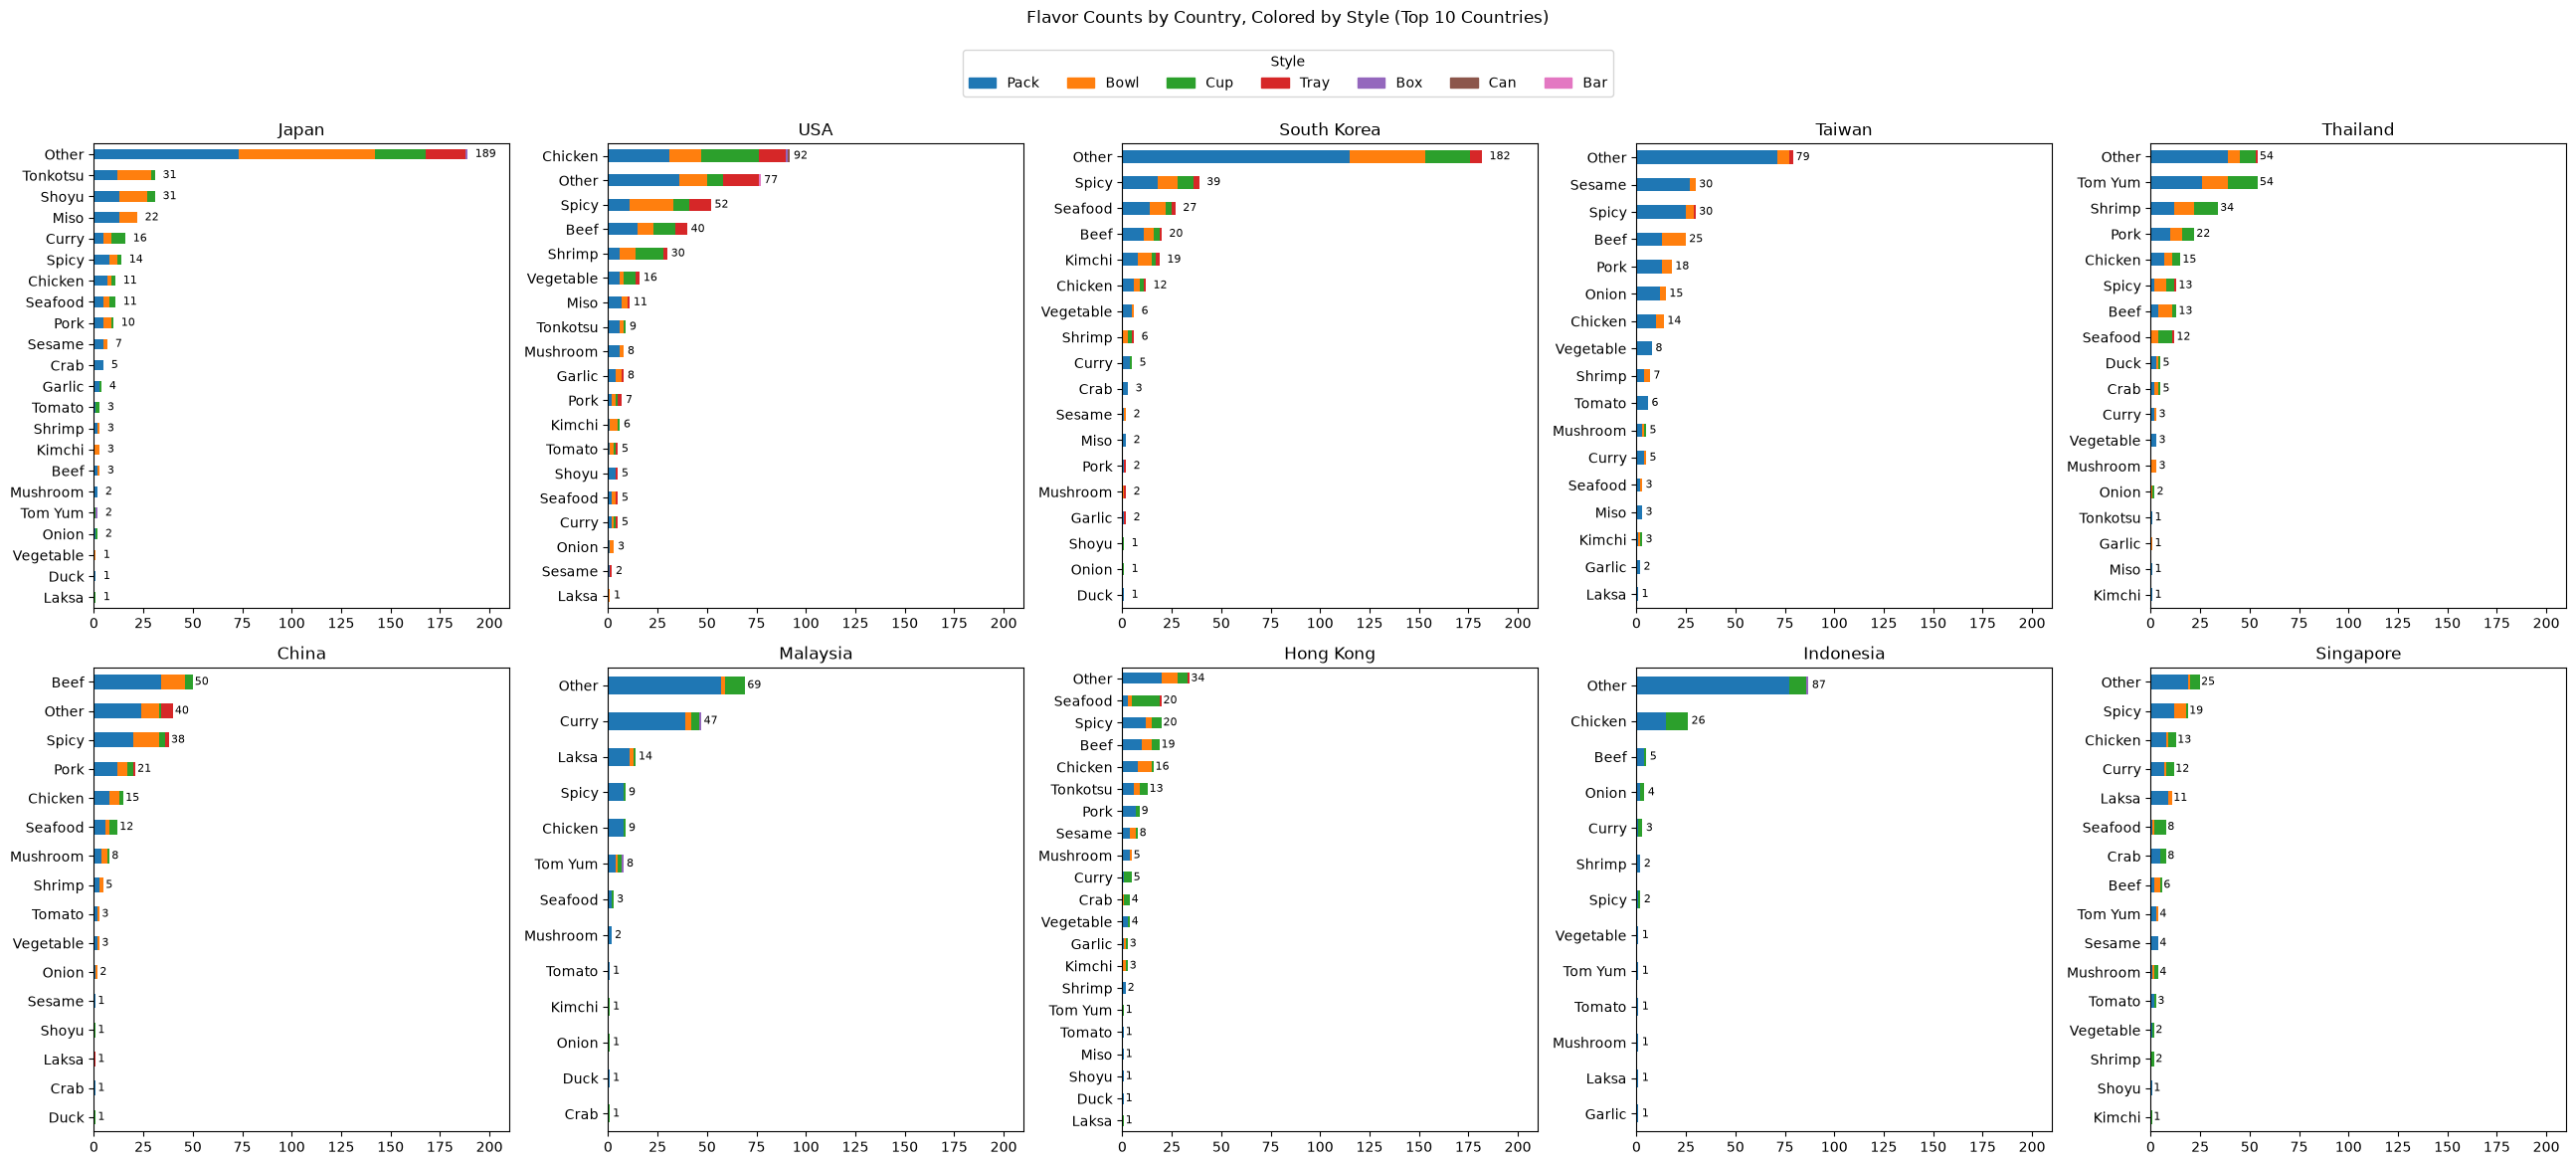

In [18]:
flavor_cols = list(flavor_keywords.keys())

melted = df_clean.melt(id_vars=["Country", "Style"], value_vars=flavor_cols, var_name="Flavor", value_name="Has_Flavor")
melted = melted[melted["Has_Flavor"]]
flavor_style_counts = melted.groupby(["Country", "Flavor", "Style"]).size().reset_index(name="Count")

top_countries = df_clean["Country"].value_counts().nlargest(10).index
style_order = df_clean["Style"].value_counts().index
style_colors = dict(zip(style_order, sns.color_palette("tab10", n_colors=len(style_order))))

fig, axes = plt.subplots(2, 5, figsize=(26, 11))
axes = axes.flatten()

for ax, country in zip(axes, top_countries):
    country_data = flavor_style_counts[flavor_style_counts["Country"] == country]
    pivot = country_data.pivot_table(index="Flavor", columns="Style", values="Count", fill_value=0)
    pivot = pivot.reindex(columns=[s for s in style_order if s in pivot.columns])
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

    pivot.plot(kind="barh", stacked=True, ax=ax, color=[style_colors[s] for s in pivot.columns], legend=False)

    totals = pivot.sum(axis=1)
    for i, total in enumerate(totals):
        ax.text(total + totals.max() * 0.02, i, str(int(total)), va="center", fontsize=8)

    ax.set_title(country)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0, 210)


for ax in axes[len(top_countries):]:
    ax.axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, color=style_colors[s]) for s in style_order]
fig.legend(handles, style_order, title="Style", loc="upper center", ncol=len(style_order), bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Flavor Counts by Country, Colored by Style (Top 10 Countries)", y=1.06)
plt.tight_layout()
plt.show()

# Overall Takeaway

As we can see there is no real way to determine which country creates teh best ramen. 